# Jaguar Re-Identification - CNN Baseline

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: []


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR = os.path.join(DATA_DIR, 'cleaned')
TRAIN_IMG_DIR = os.path.join(CLEANED_DIR, 'train')
TEST_IMG_DIR = os.path.join(CLEANED_DIR, 'test')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR = r'C:\tf\logs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)

IMG_SIZE = 224
NUM_CLASSES = 31
BATCH_SIZE = 32
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Data loading

In [3]:
train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_split.csv'))
val_df = pd.read_csv(os.path.join(CLEANED_DIR, 'val_split.csv'))
test_pairs_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train: {len(train_df)} images")
print(f"Val:   {len(val_df)} images")
print(f"Test pairs: {len(test_pairs_df)}")

Train: 1516 images
Val:   379 images
Test pairs: 137270


In [4]:
def load_images_from_df(df, img_dir):
    images, labels = [], []
    for _, row in df.iterrows():
        img = Image.open(os.path.join(img_dir, row['filename'])).convert('RGB')
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

def load_test_images(img_dir):
    test_images = {}
    for fname in sorted(os.listdir(img_dir)):
        if fname.endswith('.png'):
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            test_images[fname] = np.array(img, dtype=np.float32) / 255.0
    return test_images

print("Loading images...")
X_train, y_train = load_images_from_df(train_df, TRAIN_IMG_DIR)
X_val, y_val = load_images_from_df(val_df, TRAIN_IMG_DIR)
test_images = load_test_images(TEST_IMG_DIR)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, test: {len(test_images)}")

Loading images...
X_train: (1516, 224, 224, 3), X_val: (379, 224, 224, 3), test: 371


## 2. CNN architecture

`create_small_conv_net` but scaled for 224x224x3.  
Each conv block = 2x Conv2D + MaxPool to reduce spatial dims progressively.  
Then Flatten + Dense for classification.

In [5]:
# Input: 224x224x3
# Block 1: Conv(16) -> Conv(16) -> MaxPool -> 110x110x16
# Block 2: Conv(32) -> Conv(32) -> MaxPool -> 53x53x32
# Block 3: Conv(64) -> Conv(64) -> MaxPool -> 24x24x64
# Block 4: Conv(128) -> MaxPool -> 11x11x128
# Flatten -> 15488 -> Dense(128) -> Dense(31)

def build_cnn():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(16, (3, 3), padding='valid', activation='tanh'),
        layers.Conv2D(16, (3, 3), padding='valid', activation='tanh'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), padding='valid', activation='tanh'),
        layers.Conv2D(32, (3, 3), padding='valid', activation='tanh'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='valid', activation='tanh'),
        layers.Conv2D(64, (3, 3), padding='valid', activation='tanh'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='valid', activation='tanh'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='tanh'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='cnn_model')
    return model

cnn = build_cnn()
cnn.summary()

Model: "cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 49, 49, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 22, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,132,527 (8.13 MB)

 Trainable params: 2,132,527 (8.13 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [6]:
cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_log_dir = os.path.join(LOG_DIR, 'cnn_baseline', datetime.now().strftime('%Y%m%d-%H%M%S'))

cnn_history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.TensorBoard(log_dir=cnn_log_dir, histogram_freq=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 336ms/step - accuracy: 0.0858 - loss: 3.5823 - val_accuracy: 0.0950 - val_loss: 3.2913
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 334ms/step - accuracy: 0.0831 - loss: 3.2661 - val_accuracy: 0.0950 - val_loss: 3.1692
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - accuracy: 0.0805 - loss: 3.1824 - val_accuracy: 0.0950 - val_loss: 3.1468
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 338ms/step - accuracy: 0.0811 - loss: 3.1787 - val_accuracy: 0.0950 - val_loss: 3.1462
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 334ms/step - accuracy: 0.0811 - loss: 3.1788 - val_accuracy: 0.0950 - val_loss: 3.1464
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 333ms/step - accuracy: 0.0811 - loss: 3.1791 - val_accuracy: 0.0950 - val_loss: 3.1466
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 344ms/step - accuracy: 0.0811 - loss: 3.1793 - val_accuracy: 0.0950 - val_loss: 3.1466
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 340ms/step - accuracy: 0.0811 - loss: 3.1794 - val_accu

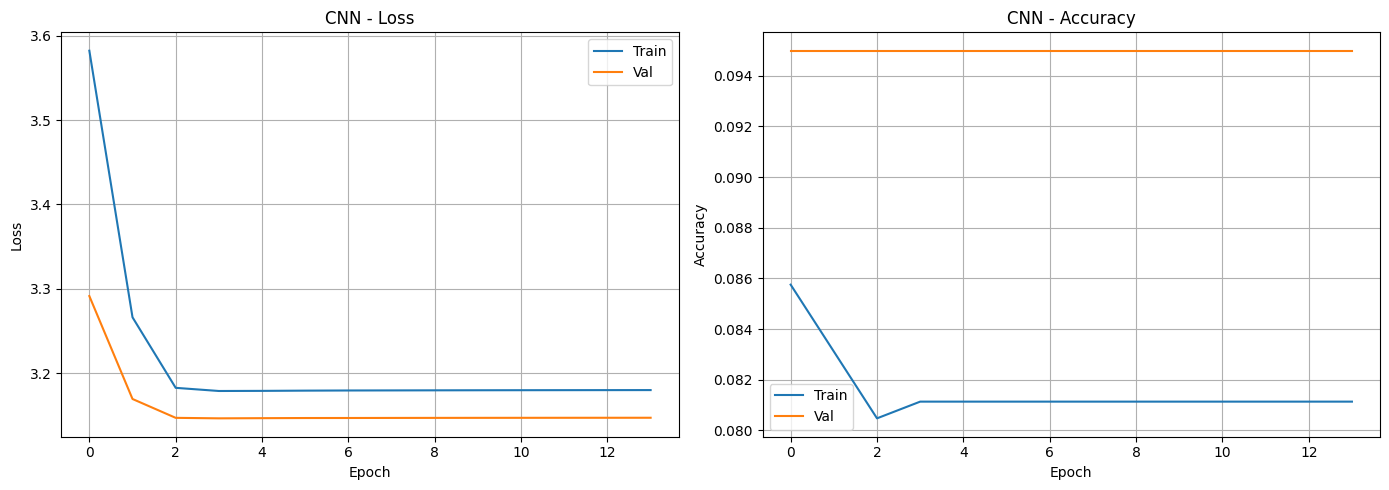

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['loss'], label='Train')
axes[0].plot(cnn_history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('CNN - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(cnn_history.history['accuracy'], label='Train')
axes[1].plot(cnn_history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('CNN - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cnn_baseline_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
train_loss, train_acc = cnn.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = cnn.evaluate(X_val, y_val, verbose=0)

print(f"CNN baseline:")
print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

CNN baseline:
  Train - Loss: 3.1452, Acc: 0.0970
  Val   - Loss: 3.1462, Acc: 0.0950


## 4. Submission

In [ ]:
final_cnn = build_cnn()
final_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

all_train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_clean.csv'))
X_all, y_all = load_images_from_df(all_train_df, TRAIN_IMG_DIR)

best_epoch = np.argmin(cnn_history.history['val_loss']) + 1
print(f"Best epoch from val: {best_epoch}")

final_cnn.fit(
    X_all, y_all,
    epochs=best_epoch,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"Final train accuracy: {final_cnn.evaluate(X_all, y_all, verbose=0)[1]:.4f}")

Best epoch from val: 4
Epoch 1/4
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 301ms/step - accuracy: 0.2871 - loss: 2.8008
Epoch 2/4
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 304ms/step - accuracy: 0.6090 - loss: 1.5775
Epoch 3/4
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 316ms/step - accuracy: 0.7520 - loss: 1.0053
Epoch 4/4
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 308ms/step - accuracy: 0.8765 - loss: 0.6309
Final train accuracy: 0.9150


In [ ]:
inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_cnn.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x)

test_filenames = sorted(test_images.keys())
test_array = np.array([test_images[f] for f in test_filenames])

test_embeddings = embedding_model.predict(test_array, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embeddings shape: {test_embeddings.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step
Embeddings shape: (371, 128)


In [11]:
query_idx = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.sum(
    test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx],
    axis=1
)
similarities = np.clip(similarities, 0, 1)

print(f"Similarities: {len(similarities)} pairs")
print(f"Min: {similarities.min():.4f}, Max: {similarities.max():.4f}, Mean: {similarities.mean():.4f}")
print(f"Unique values: {len(np.unique(np.round(similarities, 4)))}")

Similarities: 137270 pairs
Min: 0.0000, Max: 0.9995, Mean: 0.1954
Unique values: 6452


In [12]:
submission = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

submission_path = os.path.join(SUBMISSION_DIR, 'submission_cnn_baseline.csv')
submission.to_csv(submission_path, index=False)

print(f"Saved: {submission_path}")
display(submission.head(10))

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)

Saved: c:\Users\Frédéric\Developer\kaggle_jaguar_classification\submissions\submission_cnn_baseline.csv


,row_id,similarity
0,0,0.382154
1,1,0.267931
2,2,0.000000
3,3,0.029302
4,4,0.469630
5,5,0.420557
6,6,0.447408
7,7,0.428403
8,8,0.398180
9,9,0.476639


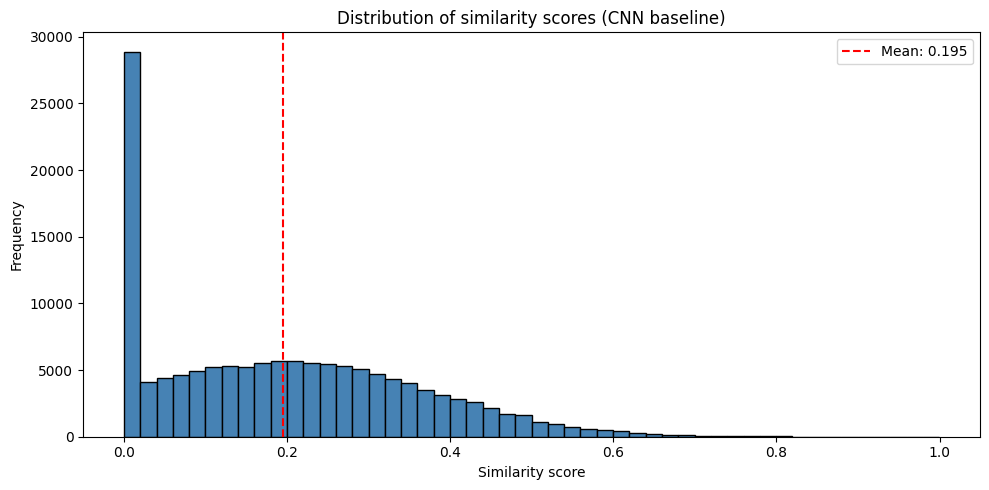

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.set_xlabel('Similarity score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of similarity scores (CNN baseline)')
ax.axvline(x=similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'similarity_distribution_cnn.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

In [14]:
print(f"""
CNN baseline:
  Train: {train_acc:.4f}, Val: {val_acc:.4f}
  Best epoch: {best_epoch}
  Embedding dim: {test_embeddings.shape[1]}

vs MLP baseline (notebook 03):
  Linear val_acc ~0.53, MLP val_acc ~0.10

Submission -> {submission_path}
""")


CNN baseline:
  Train: 0.0970, Val: 0.0950
  Best epoch: 4
  Embedding dim: 128

vs MLP baseline (notebook 03):
  Linear val_acc ~0.53, MLP val_acc ~0.10

Submission -> c:\Users\Frédéric\Developer\kaggle_jaguar_classification\submissions\submission_cnn_baseline.csv

